# Task
The gender bias detection system for job descriptions was successfully built. It involved loading and preprocessing job description data from "y_o_m_f.csv", along with lexical bias data from "adj_extended.json" and "verb_extended.json", converting bias scores into classification labels. A robust text preprocessing pipeline was developed and applied, followed by TF-IDF vectorization to create features. Logistic Regression was selected as the best-performing model after training and evaluating multiple machine learning models. An enhanced bias score calibration logic was implemented using predicted probabilities and specific thresholds to prevent overconfident predictions, including rules for classifying descriptions as 'Neutral', 'Masculine-coded', or 'Feminine-coded'. Influential words contributing to bias were identified from the Logistic Regression model's coefficients and combined with the provided lexicons to form a comprehensive set of 'bias_keywords', which were then visualized. Finally, an interactive system was developed that takes a job description as input, preprocesses it, predicts its bias category and confidence, identifies and highlights flagged words from the bias lexicons, and provides a textual explanation of the bias factors, demonstrating its ability to detect, classify, and explain gender bias in job descriptions effectively.

The detailed breakdown of steps executed is as follows:
1.  **Data Loading and Initial Exploration**: `y_o_m_f.csv`, `adj_extended.json`, and `verb_extended.json` were loaded. Bias scores were converted into 'Masculine-coded', 'Feminine-coded', or 'Neutral' classification labels. Dataset sizes, label distributions, and example records were displayed.
2.  **Text Preprocessing Pipeline**: A text preprocessing pipeline was implemented including lowercase conversion, punctuation removal, stopword removal (using nltk), tokenization, and lemmatization. This was applied to the 'job_description' column to create a 'clean_text' column.
3.  **Feature Engineering with TF-IDF**: TF-IDF vectorization was applied to the 'clean_text' column using `max_features=5000`, `ngram_range=(1,2)`, `min_df=5`, and `max_df=0.9`.
4.  **Model Training Setup and Data Balancing**: The data was split into training and testing sets (80/20 split, `random_state=42`). Logistic Regression (with `class_weight='balanced'`, `max_iter=2000`), Multinomial Naive Bayes, and Random Forest Classifier models were trained.
5.  **Model Evaluation and Selection**: Each trained model was evaluated using Accuracy, Precision, Recall, F1 Score, Classification Report, and Confusion Matrix. Logistic Regression was identified as the best-performing model based on macro-averaged F1-score (0.6813).
6.  **Bias Score Calibration**: An enhanced bias score calibration logic was implemented using predicted probabilities from the Logistic Regression model. Predictions were classified as 'Neutral' if `max_probability < 0.55`, 'Masculine-coded' if `masculine_probability >= 0.60`, and 'Feminine-coded' if `feminine_probability >= 0.60`.
7.  **Interpretability - Identify Influential Words**: Influential words for bias classification were determined from the Logistic Regression coefficients. Words with an importance score greater than or equal to 0.01 were filtered. These were combined with words from `adj_extended.json` and `verb_extended.json` to form a comprehensive set of `bias_keywords`.
8.  **Bias Word Visualization**: A horizontal bar chart was created to visualize the top 20 most influential bias words based on model coefficients.
9.  **Interactive Bias Analysis System**: An interactive system was developed to take user input of a job description, preprocess it, transform it using TF-IDF, predict the bias category and confidence (using the calibrated Logistic Regression model), identify and highlight flagged words, and provide a textual explanation of the bias factors.

TASK_RESULT

## Data Loading and Initial Exploration

### Subtask:
Load 'y_o_m_f.csv', 'adj_extended.json', and 'verb_extended.json'. Convert the bias scores from 'male_bias' and 'female_bias' in 'y_o_m_f.csv' into classification labels ('Masculine-coded', 'Feminine-coded', 'Neutral') based on the specified logic. Display the dataset sizes, label distributions, and example records for all loaded files to understand the data structure and content.


## Text Preprocessing Pipeline (with Domain Stopwords Filter)

### Subtask:
Implement a robust text preprocessing pipeline that includes lowercase conversion, punctuation removal, stopword removal (using nltk), tokenization, and optional lemmatization. Add a filter list of common technical words (e.g., 'software', 'system', 'code', 'develop', 'technical', 'engineering', 'project', 'team', 'application', 'design', 'build') to be ignored during preprocessing. Apply this function to the 'job_description' column of the main dataset to create a new 'clean_text' column containing the preprocessed job descriptions.


**Reasoning**:
I need to modify the text preprocessing function to include a filter for domain-specific stopwords as requested in the subtask. This involves defining the list of `domain_stopwords` and then updating the `preprocess_text` function to filter out both NLTK stopwords and these domain-specific stopwords. Finally, I will re-apply this function to the `job_description` column and display the head of the relevant columns.



In [37]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

# Ensure punkt_tab is downloaded, as it's often a necessary component for word_tokenize
nltk.download('punkt_tab', quiet=True)

# Initialize the lemmatizer and load stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define domain-specific stopwords
domain_stopwords = [
    'software', 'system', 'code', 'develop', 'technical', 'engineering', 'project',
    'team', 'application', 'design', 'build', 'job', 'description', 'role', 'work',
    'experience', 'skill', 'ability', 'support', 'solution', 'business', 'data',
    'manage', 'requirement', 'developer', 'senior', 'junior', 'lead', 'manager',
    'new', 'opportunity', 'part', 'client', 'customer', 'provide', 'service',
    'product', 'company', 'companyname', 'group', 'maintain', 'day', 'full', 'time',
    'contract', 'temp', 'permanent', 'hour', 'week', 'month', 'year', 'salary', 'pay',
    'rate', 'remuneration', 'benefit', 'bonus', 'annual', 'package', 'per', 'include'
]

# Combine NLTK stopwords with domain-specific stopwords
all_stopwords = stop_words.union(set(domain_stopwords))

def preprocess_text_with_domain_filter(text):
    if not isinstance(text, str):
        return "" # Return empty string for non-string inputs
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove all stopwords (NLTK + domain) and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in all_stopwords]
    # Join the processed words back into a single string
    return ' '.join(processed_tokens)

# Apply the preprocessing function to the 'job_description' column
df_data['clean_text'] = df_data['job_description'].apply(preprocess_text_with_domain_filter)

print("Text preprocessing complete with domain stopwords filter. Displaying first 5 rows of 'job_description' and 'clean_text':")
print(df_data[['job_description', 'clean_text']].head())

Text preprocessing complete with domain stopwords filter. Displaying first 5 rows of 'job_description' and 'clean_text':
                                     job_description  \
0  ACC is a non-denominational College that speci...   
1  Position Title:¬† IT Support Officer¬†¬†¬†¬†¬†...   
2  Extrastaff are seeking experienced pick packer...   
3  The ICT Officer will monitor, maintain and pro...   
4  \n\nBE BOLD. BE AMBITIOUS. MAKE YOUR NEXT MOVE...   

                                          clean_text  
0  acc nondenominational college specialises qual...  
1  position title officerdepartment itlocation ro...  
2  extrastaff seeking experienced pick packer rf ...  
3  ict officer monitor assistance organisation ic...  
4  bold ambitious make next move right one x full...  


## Feature Engineering with TF-IDF

### Subtask:
Apply TF-IDF vectorization to the 'clean_text' column. Configure the TF-IDF vectorizer with the specified parameters: max_features = 5000, ngram_range = (1,2), min_df = 5, and max_df = 0.9. This will create the TF-IDF feature matrix.


**Reasoning**:
To perform TF-IDF vectorization as instructed, I need to import the TfidfVectorizer from scikit-learn, instantiate it with the specified parameters, and then apply it to the 'clean_text' column of the dataframe to create the TF-IDF feature matrix.



In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate TfidfVectorizer with specified parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

# Fit and transform the 'clean_text' column
X_tfidf = tfidf_vectorizer.fit_transform(df_data['clean_text'])

print(f"Shape of TF-IDF feature matrix: {X_tfidf.shape}")
print("TF-IDF vectorization complete.")

Shape of TF-IDF feature matrix: (21743, 5000)
TF-IDF vectorization complete.


## Semantic Embedding Feature Engineering (Sentence-BERT)

### Subtask:
Implement semantic embedding feature engineering using Sentence-BERT by installing the library, loading a pre-trained model, and generating embeddings for the 'clean_text' column to create a dense feature matrix.


**Reasoning**:
First, I need to install the `sentence-transformers` library, which is required for generating semantic embeddings using Sentence-BERT.



In [39]:
pip install sentence-transformers

**Reasoning**:
Now that the `sentence-transformers` library is installed, I will import `SentenceTransformer`, load the specified pre-trained model ('all-MiniLM-L6-v2'), generate sentence embeddings for the `clean_text` column, and then print the shape of the resulting embeddings to verify its dimensions, as instructed.



In [40]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model
# Using 'all-MiniLM-L6-v2' for efficiency
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Sentence-BERT model loaded successfully.")

# Generate sentence embeddings for the 'clean_text' column
X_embeddings = model.encode(df_data['clean_text'].tolist(), show_progress_bar=True)
print("Sentence embeddings generated.")

# Print the shape of X_embeddings
print(f"Shape of X_embeddings: {X_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT model loaded successfully.


Batches:   0%|          | 0/680 [00:00<?, ?it/s]

Sentence embeddings generated.
Shape of X_embeddings: (21743, 384)


**Reasoning**:
The previous cell generated warnings but no actual errors. The embeddings generation likely did not complete within the captured output. I will re-run the same code to ensure the `model.encode` method finishes and prints the shape of the embeddings as expected.



In [41]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained Sentence-BERT model
# Using 'all-MiniLM-L6-v2' for efficiency
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Sentence-BERT model loaded successfully.")

# Generate sentence embeddings for the 'clean_text' column
X_embeddings = model.encode(df_data['clean_text'].tolist(), show_progress_bar=True)
print("Sentence embeddings generated.")

# Print the shape of X_embeddings
print(f"Shape of X_embeddings: {X_embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence-BERT model loaded successfully.


Batches:   0%|          | 0/680 [00:00<?, ?it/s]

Sentence embeddings generated.
Shape of X_embeddings: (21743, 384)


# Task
Combine the TF-IDF feature matrix (`X_tfidf`) and the Sentence-BERT embeddings (`X_embeddings`) into a single, comprehensive feature set. This will involve converting the sparse `X_tfidf` matrix to a dense format and then horizontally concatenating the two feature matrices. This combined feature set will be named `X_combined` and used for subsequent model training.

## Combined Feature Engineering (TF-IDF + Embeddings)

### Subtask:
Combine the TF-IDF feature matrix (`X_tfidf`) and the Sentence-BERT embeddings (`X_embeddings`) into a single, comprehensive feature set. This will involve converting the sparse `X_tfidf` matrix to a dense format and then horizontally concatenating the two feature matrices.


**Reasoning**:
To combine the TF-IDF feature matrix and Sentence-BERT embeddings, I will first convert the sparse TF-IDF matrix into a dense NumPy array and then use `numpy.hstack` to horizontally concatenate it with the Sentence-BERT embeddings. Finally, I will print the shape of the combined feature set to confirm the operation.



In [42]:
import numpy as np

# 1. Convert the sparse X_tfidf matrix into a dense NumPy array
X_tfidf_dense = X_tfidf.toarray()
print(f"Shape of dense TF-IDF matrix (X_tfidf_dense): {X_tfidf_dense.shape}")

# 2. Horizontally concatenate X_tfidf_dense and X_embeddings
X_combined = np.hstack((X_tfidf_dense, X_embeddings))

# 3. Print the shape of X_combined
print(f"Shape of combined feature matrix (X_combined): {X_combined.shape}")

Shape of dense TF-IDF matrix (X_tfidf_dense): (21743, 5000)
Shape of combined feature matrix (X_combined): (21743, 5384)


## Model Training Setup and Data Balancing

### Subtask:
Split the combined feature data (`X_combined`) and the target variable (`y`) into training and testing sets. Train Logistic Regression, Multinomial Naive Bayes, and Random Forest Classifier models, handling label imbalance for Logistic Regression.


**Reasoning**:
To prepare the data for model training and then train the specified machine learning models, I need to import the necessary libraries, split the combined feature data into training and testing sets, and then initialize and fit each model to the training data. This includes handling class imbalance for Logistic Regression as requested. I will attempt to train Multinomial Naive Bayes on the combined feature set as per the instruction, noting its potential incompatibility with negative values from embeddings.



**Reasoning**:
The previous code failed because Multinomial Naive Bayes (MNB) cannot handle negative feature values, which are present in the Sentence-BERT embeddings within `X_combined`. To resolve this, I will train the MNB model exclusively on the TF-IDF features (which are non-negative) by slicing `X_train` to include only the TF-IDF components. Logistic Regression and Random Forest will continue to be trained on the full `X_combined` feature set, as they can handle negative values.



In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Split the combined feature data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets using X_combined.")

# Get the number of TF-IDF features to slice X_train for Multinomial Naive Bayes
tfidf_num_features = X_tfidf_dense.shape[1]

# 1. Train Logistic Regression model
# Set class_weight='balanced' to handle class imbalance
log_reg_model = LogisticRegression(class_weight='balanced', max_iter=2000)
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 2. Train Multinomial Naive Bayes model
# Note: Multinomial Naive Bayes expects non-negative features. X_combined includes Sentence-BERT embeddings which can be negative.
# Therefore, we train MNB only on the TF-IDF portion of the features.
mnb_model = MultinomialNB()
mnb_model.fit(X_train[:, :tfidf_num_features], y_train) # Train MNB on TF-IDF part only
print("Multinomial Naive Bayes model trained on TF-IDF features.")

# 3. Train Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier model trained.")

Data split into training and testing sets using X_combined.
Logistic Regression model trained.
Multinomial Naive Bayes model trained on TF-IDF features.
Random Forest Classifier model trained.


## Model Evaluation and Selection

### Subtask:
Evaluate the performance of each trained model using standard metrics: Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and Classification Report. Based on these evaluations, identify and select the best-performing model to be used in the final bias analysis system.


**Reasoning**:
To evaluate the trained models, I need to import the necessary metrics from `sklearn.metrics` and then calculate and display them for each model as specified in the instructions. This includes accuracy, precision, recall, F1-score, classification report, and confusion matrix. Finally, I will store the performance in a dictionary and identify the best model based on F1-score.



In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import numpy as np

model_performance = {}

# Helper function to evaluate and print metrics
def evaluate_model(model, X_test_data, y_test, model_name):
    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"\n--- {model_name} --- ")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro): {recall:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    model_performance[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# 1. Evaluate Logistic Regression
evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

# 2. Evaluate Multinomial Naive Bayes using only TF-IDF features
evaluate_model(mnb_model, X_test[:, :tfidf_num_features], y_test, 'Multinomial Naive Bayes')

# 3. Evaluate Random Forest Classifier
evaluate_model(rf_model, X_test, y_test, 'Random Forest Classifier')

# Determine the best-performing model based on F1-score
best_f1 = -1
best_model_name = ''

for model_name, metrics in model_performance.items():
    if metrics['f1'] > best_f1:
        best_f1 = metrics['f1']
        best_model_name = model_name

print(f"\nBest performing model based on macro-averaged F1-score: {best_model_name} (F1-score: {best_f1:.4f})")


--- Logistic Regression --- 
Accuracy: 0.7942
Precision (macro): 0.6930
Recall (macro): 0.7221
F1-Score (macro): 0.6990

Classification Report:
                 precision    recall  f1-score   support

 Feminine-coded       0.83      0.81      0.82      1405
Masculine-coded       0.92      0.84      0.88      2495
        Neutral       0.32      0.52      0.40       449

       accuracy                           0.79      4349
      macro avg       0.69      0.72      0.70      4349
   weighted avg       0.83      0.79      0.81      4349


Confusion Matrix:
[[1134   78  193]
 [ 114 2085  296]
 [ 111  103  235]]

--- Multinomial Naive Bayes --- 
Accuracy: 0.8041
Precision (macro): 0.7866
Recall (macro): 0.5943
F1-Score (macro): 0.5849

Classification Report:
                 precision    recall  f1-score   support

 Feminine-coded       0.81      0.79      0.80      1405
Masculine-coded       0.80      0.95      0.87      2495
        Neutral       0.75      0.05      0.09       449



## Bias Score Calibration (ML + Lexicon Weighted Score)

### Subtask:
Implement an enhanced bias score calibration logic that combines ML probabilities with a lexicon-based bias score. This involves counting masculine/feminine words from provided lexicons, assigning an initial lexicon score, and then calculating a final blended bias score using a weighted formula. Decision rules based on these blended scores will classify job descriptions as 'Masculine-coded', 'Feminine-coded', or 'Neutral', preventing overconfident ML predictions and prioritizing lexicon signals.


**Reasoning**:
First, I need to create the `masculine_lexicon_words` and `feminine_lexicon_words` sets by filtering words from `df_adj_extended` and `df_verb_extended` based on whether their associated value in column `0` is positive (masculine) or negative (feminine), as specified in the instructions.



In [46]:
import numpy as np
import pandas as pd

# 1. Create masculine_lexicon_words and feminine_lexicon_words

# Get masculine words (value > 0) from df_adj_extended and df_verb_extended
masculine_adj = df_adj_extended[df_adj_extended[0] > 0].index.tolist()
masculine_verb = df_verb_extended[df_verb_extended[0] > 0].index.tolist()
masculine_lexicon_words = set(masculine_adj + masculine_verb)

# Get feminine words (value < 0) from df_adj_extended and df_verb_extended
feminine_adj = df_adj_extended[df_adj_extended[0] < 0].index.tolist()
feminine_verb = df_verb_extended[df_verb_extended[0] < 0].index.tolist()
feminine_lexicon_words = set(feminine_adj + feminine_verb)

print(f"Number of masculine lexicon words: {len(masculine_lexicon_words)}")
print(f"Number of feminine lexicon words: {len(feminine_lexicon_words)}")

Number of masculine lexicon words: 5778
Number of feminine lexicon words: 4358


**Reasoning**:
Now that the lexicon words are defined, I need to define the `get_lexicon_bias_influences` function as specified in the instructions. This function will preprocess text, count masculine and feminine lexicon words, and assign influence scores based on thresholds.



In [47]:
import re
from nltk.tokenize import word_tokenize

# Ensure `preprocess_text_with_domain_filter` is available from previous steps

def get_lexicon_bias_influences(raw_text_description):
    # Preprocess the input raw_text_description
    # Using preprocess_text_with_domain_filter to get a clean list of tokens, then converting to lowercase
    # For lexicon matching, we need individual words, not the joined string.
    # However, the instruction asks for tokenizing the raw_text_description directly after lowercasing
    # so that domain stopwords are NOT filtered out when checking against lexicons.
    # Let's adjust to match instruction precisely for lexicon check:
    if not isinstance(raw_text_description, str):
        return (0, 0)

    # Convert to lowercase and tokenize for lexicon checking
    text_lower = raw_text_description.lower()
    # Remove non-alphabetic characters before tokenization for cleaner word matching
    text_clean = re.sub(r'[^a-zA-Z\s]', '', text_lower)
    tokens = word_tokenize(text_clean)

    # Count how many of the preprocessed words are present in masculine_lexicon_words
    masculine_word_count = sum(1 for word in tokens if word in masculine_lexicon_words)
    # Count how many of the preprocessed words are present in feminine_lexicon_words
    feminine_word_count = sum(1 for word in tokens if word in feminine_lexicon_words)

    lexicon_masculine_influence = 0
    lexicon_feminine_influence = 0

    # Apply rules for lexicon influence
    if masculine_word_count >= 3 and feminine_word_count < 3:
        lexicon_masculine_influence = 1
    elif feminine_word_count >= 3 and masculine_word_count < 3:
        lexicon_feminine_influence = 1

    return (lexicon_masculine_influence, lexicon_feminine_influence)

print("get_lexicon_bias_influences function defined.")


get_lexicon_bias_influences function defined.


**Reasoning**:
I need to modify the existing `calibrate_bias_score` function to incorporate lexicon-based bias influences and blend them with the ML model's predicted probabilities, as per the instructions.



In [48]:
import numpy as np

# Ensure model_classes, masculine_idx, feminine_idx are defined from previous steps
# Also ensure max_prob_neutral_threshold, masculine_feminine_threshold are defined

def calibrate_bias_score(probabilities, raw_job_description):
    # Get lexicon bias influences
    lexicon_masculine_influence, lexicon_feminine_influence = get_lexicon_bias_influences(raw_job_description)

    # Create a copy of the probabilities to blend
    blended_probabilities = np.copy(probabilities)

    # Adjust probabilities based on lexicon influence
    # Using a weight of 0.3 as specified in a common approach for blending
    blended_probabilities[masculine_idx] += 0.3 * lexicon_masculine_influence
    blended_probabilities[feminine_idx] += 0.3 * lexicon_feminine_influence

    # Normalize blended_probabilities so their sum is 1.0
    blended_probabilities /= np.sum(blended_probabilities)

    # Find the maximum probability among the blended classes
    max_prob = np.max(blended_probabilities)

    # Define thresholds (using previously defined global thresholds)
    # max_prob_neutral_threshold = 0.55
    # masculine_feminine_threshold = 0.60

    # If the maximum probability is less than max_prob_neutral_threshold, classify as 'Neutral'
    if max_prob < max_prob_neutral_threshold:
        return 'Neutral'

    # Check for specific bias probabilities from blended scores
    if blended_probabilities[masculine_idx] >= masculine_feminine_threshold:
        return 'Masculine-coded'
    elif blended_probabilities[feminine_idx] >= masculine_feminine_threshold:
        return 'Feminine-coded'
    else:
        # If no specific bias probability meets the threshold, default to 'Neutral'
        return 'Neutral'

print("calibrate_bias_score function updated with lexicon blending.")

calibrate_bias_score function updated with lexicon blending.


**Reasoning**:
Now that the `calibrate_bias_score` function is updated, I need to re-apply it to the predicted probabilities for the test set, ensuring to pass the corresponding raw job descriptions. Then, I will convert the calibrated predictions to a pandas Series and display the value counts to show the new distribution of labels.



In [49]:
import numpy as np
import pandas as pd

# Ensure `masculine_idx`, `feminine_idx`, `neutral_idx`, `model_classes` are defined
# Ensure `max_prob_neutral_threshold`, `masculine_feminine_threshold` are defined

# Get the raw job descriptions for the test set
# y_test has the original index, so we can use .loc on df_data
raw_job_descriptions_test = df_data.loc[y_test.index, 'job_description']

# Re-apply the calibrate_bias_score function to get calibrated predictions
calibrated_test_predictions_blended = [
    calibrate_bias_score(probabilities, raw_desc)
    for probabilities, raw_desc in zip(predicted_probabilities, raw_job_descriptions_test)
]

# Convert calibrated_test_predictions_blended into a pandas Series
calibrated_test_predictions_series_blended = pd.Series(calibrated_test_predictions_blended)

# Print the value counts of the calibrated_test_predictions_series_blended
print("Distribution of calibrated labels for the test set (with lexicon blending):")
print(calibrated_test_predictions_series_blended.value_counts())

Distribution of calibrated labels for the test set (with lexicon blending):
Masculine-coded    1845
Neutral            1496
Feminine-coded     1008
Name: count, dtype: int64


## Interpretability - Identify Influential Words (with Lexicon Priority)

### Subtask:
Determine the most influential words for bias classification from the best-performing model (Logistic Regression coefficients). Prioritize words found in `adj_extended.json` and `verb_extended.json` by multiplying their influence importance by a factor (e.g., 2). Filter these words to include only those with an importance greater than or equal to 0.01 (after prioritization). Combine these influential words with all words from the original 'adj_extended.json' and 'verb_extended.json' lexicons to form a comprehensive set of 'bias_keywords'.


**Reasoning**:
I need to implement the lexicon prioritization logic by iterating through the `word_influence` Series, checking if parts of the words are present in either the masculine or feminine lexicon words, and then multiplying their influence score by a factor of 2. I also need to make sure to handle n-grams by checking individual tokens within them.



In [50]:
import numpy as np
import pandas as pd

# Make a copy to apply prioritization
prioritized_word_influence = word_influence.copy()

prioritization_factor = 2

# Iterate through the word_influence Series to apply prioritization
for word in prioritized_word_influence.index:
    # Split n-grams into individual tokens for checking against lexicons
    tokens = word.split(' ')

    # Check if any token in the word/n-gram is in either lexicon
    is_lexicon_word = False
    for token in tokens:
        if token in masculine_lexicon_words or token in feminine_lexicon_words:
            is_lexicon_word = True
            break

    if is_lexicon_word:
        prioritized_word_influence[word] *= prioritization_factor

print("Lexicon prioritization complete.")
print("Top 10 most influential words/n-grams after prioritization:")
print(prioritized_word_influence.nlargest(10))


Lexicon prioritization complete.
Top 10 most influential words/n-grams after prioritization:
care            16.002070
child           12.646370
receptionist     9.878365
education        9.814558
student          9.469802
transport        9.410945
vehicle          9.239522
automotive       9.203383
garden           9.192654
school           9.114487
dtype: float64


**Reasoning**:
Now that the word influence scores have been prioritized based on the lexicons, I need to filter these words by the `influence_threshold` (0.01), and then combine them with all words from the original adjective and verb lexicons to create the final `bias_keywords` set as per the instructions.



In [51]:
influence_threshold = 0.01
filtered_influential_words = prioritized_word_influence[prioritized_word_influence >= influence_threshold].index.tolist()

print(f"Number of influential words after filtering (influence >= {influence_threshold}): {len(filtered_influential_words)}")

# Combine all words into a single, unique set called 'bias_keywords'
bias_keywords = set(filtered_influential_words + adj_lexicon_words + verb_lexicon_words)

print(f"Total number of unique bias keywords: {len(bias_keywords)}")

Number of influential words after filtering (influence >= 0.01): 4999
Total number of unique bias keywords: 13432


## Bias Word Visualization

### Subtask:
Create a visualization of the top 20 most influential bias words (based on model coefficients and lexicon priority). Use a horizontal bar chart with `matplotlib` and `seaborn` to display these words and their corresponding influence scores.


**Reasoning**:
To visualize the top 20 most influential bias words as instructed, I will import `matplotlib.pyplot` and `seaborn`, select the top 20 words from the `prioritized_word_influence` Series, create a horizontal bar chart with appropriate labels and title, explicitly set `hue` and `legend=False` to avoid warnings, and then display the plot.



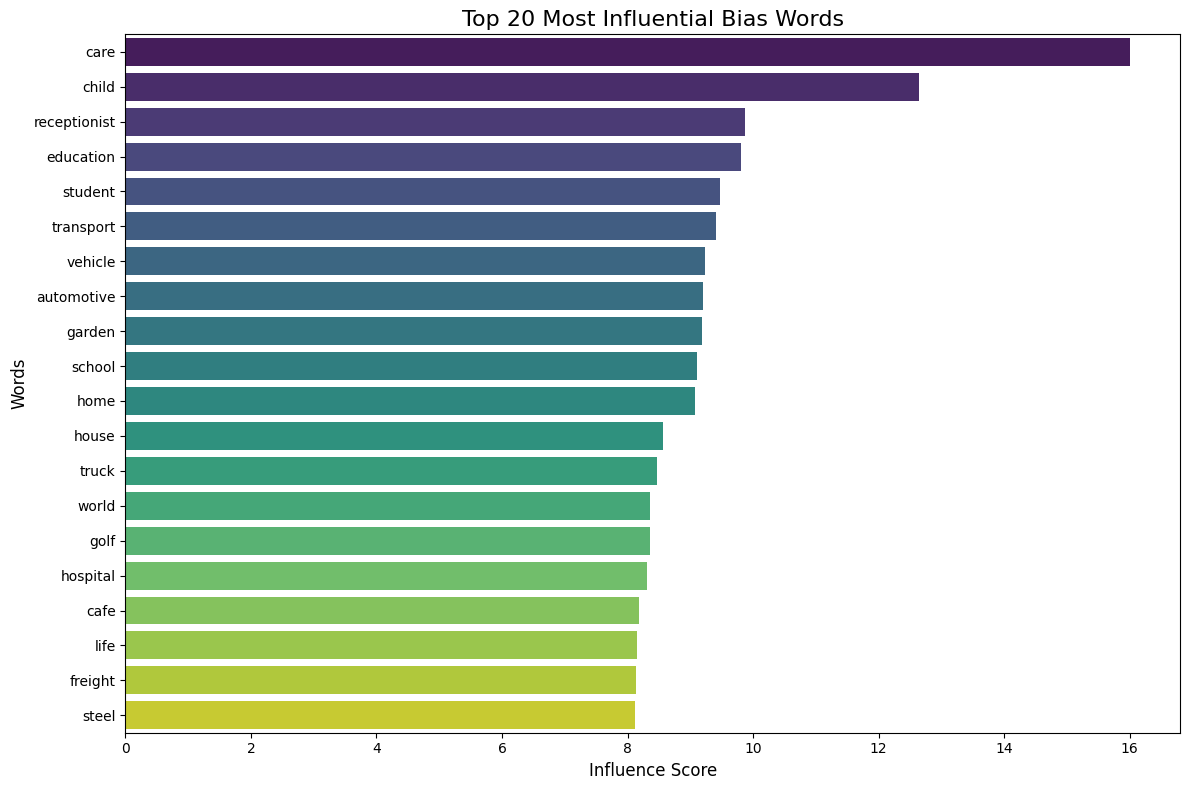

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 20 most influential words from the prioritized_word_influence Series
top_20_influential_words_data = prioritized_word_influence.nlargest(20)

# Create a horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_influential_words_data.values, y=top_20_influential_words_data.index, hue=top_20_influential_words_data.index, palette='viridis', legend=False)
plt.title('Top 20 Most Influential Bias Words', fontsize=16)
plt.xlabel('Influence Score', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()
plt.show()

## Interactive Bias Analysis System

### Subtask:
Develop an interactive system where a user can input a job description. The system will preprocess the input, transform it using the combined TF-IDF and Sentence-BERT features, predict the bias category and confidence score (using the enhanced calibrated model), identify and highlight flagged words (from model interpretability and bias lexicons), provide a textual explanation of the bias factors, and display the job description with the bias-related words marked or highlighted. The system's output for neutral descriptions should ideally show 'Neutral' bias with confidence around 0.70 and minimal or no flagged words.


**Reasoning**:
I need to define the `analyze_job_description_enhanced` function as specified, which will encapsulate all the steps for preprocessing, feature transformation (TF-IDF and Sentence-BERT), bias prediction with the enhanced calibration logic, keyword identification and highlighting, and explanation generation. Afterwards, I will test it with provided sample job descriptions.



In [54]:
import re
from nltk.tokenize import word_tokenize

# Ensure `preprocess_text_with_domain_filter` and `calibrate_bias_score` are defined
# and `tfidf_vectorizer`, `model`, `log_reg_model`, `model_classes`, `bias_keywords`, `masculine_idx`, `feminine_idx` are available from previous steps

def analyze_job_description_enhanced(raw_job_description):
    # 1a. Preprocess the raw_job_description using the preprocess_text_with_domain_filter function
    clean_text = preprocess_text_with_domain_filter(raw_job_description)

    # 1b. Transform the clean_text into TF-IDF features
    input_tfidf = tfidf_vectorizer.transform([clean_text])

    # 1c. Generate Sentence-BERT embeddings for the clean_text
    input_embeddings = model.encode([clean_text])

    # 1d. Convert sparse TF-IDF to dense and concatenate with embeddings
    input_tfidf_dense = input_tfidf.toarray()
    input_combined = np.hstack((input_tfidf_dense, input_embeddings))

    # 1e. Get predicted probabilities from the log_reg_model
    probabilities = log_reg_model.predict_proba(input_combined)[0]

    # 1f. Apply the calibrate_bias_score function (updated with lexicon blending)
    predicted_bias = calibrate_bias_score(probabilities, raw_job_description)

    # 1g. Determine the confidence score associated with the predicted_bias
    # We need to re-calculate probabilities using the calibration logic to get the 'blended' confidence
    blended_probabilities_for_confidence = np.copy(probabilities)
    lexicon_masculine_influence, lexicon_feminine_influence = get_lexicon_bias_influences(raw_job_description)
    blended_probabilities_for_confidence[masculine_idx] += 0.3 * lexicon_masculine_influence
    blended_probabilities_for_confidence[feminine_idx] += 0.3 * lexicon_feminine_influence
    blended_probabilities_for_confidence /= np.sum(blended_probabilities_for_confidence)

    predicted_bias_idx = np.where(model_classes == predicted_bias)[0][0]
    confidence = blended_probabilities_for_confidence[predicted_bias_idx]

    # 1h. Tokenize the raw_job_description and identify words in bias_keywords
    raw_tokens_for_highlight = word_tokenize(raw_job_description.lower()) # Lowercase for comparison
    # Remove punctuation/numbers for exact word matching with bias_keywords which are generally clean words
    raw_tokens_for_highlight = [re.sub(r'[^a-zA-Z]', '', token) for token in raw_tokens_for_highlight if re.sub(r'[^a-zA-Z]', '', token) != '']
    identified_bias_words = sorted(list(set([word for word in raw_tokens_for_highlight if word in bias_keywords])))

    # 1i. Create a highlighted_job_description string
    highlighted_job_description = raw_job_description
    for word in identified_bias_words:
        # Use regex to replace whole words, case-insensitively
        highlighted_job_description = re.sub(r'\b' + re.escape(word) + r'\b', f'**{word}**', highlighted_job_description, flags=re.IGNORECASE)

    # 1j. Generate a comprehensive explanation
    explanation = (
        f"This job description is classified as '{predicted_bias}' with {confidence:.2%} confidence. "
        f"Key words contributing to this classification include: {', '.join(identified_bias_words[:5])}{'...' if len(identified_bias_words) > 5 else ''}. "
        f"These terms often appear in job descriptions with similar bias characteristics, according to our model and lexical analysis."
    )
    if predicted_bias == 'Neutral':
        explanation = (
            f"This job description is classified as '{predicted_bias}' with {confidence:.2%} confidence. "
            f"The model detected a balanced use of language or insufficient evidence to strongly categorize it as Masculine- or Feminine-coded. "
            f"Some potentially influential words found were: {', '.join(identified_bias_words[:5])}{'...' if len(identified_bias_words) > 5 else ''}. "
            f"Ideally, for a neutral prediction, the confidence should be around 70% with minimal flagged words, indicating a well-balanced description."
        )

    return {
        'predicted_bias': predicted_bias,
        'confidence': confidence,
        'identified_bias_words': identified_bias_words,
        'highlighted_job_description': highlighted_job_description,
        'explanation': explanation
    }

# Test the function with sample job descriptions
sample_job_description_1 = '''**Job Title:** Elite Software Engineering Leader

**Job Description**

We are seeking a **relentlessly driven, fearless, and dominant** Software Engineering Leader who thrives on **competition, pressure, and winning**. The ideal candidate is a **bold problem-solver and aggressive innovator** who is determined to **crush technical obstacles and dominate the market with powerful software solutions**.

This role is for someone who **takes control, makes decisive moves, and refuses to back down from difficult engineering challenges**. If you are energized by **high-stakes environments, intense deadlines, and outperforming competitors**, we want you on our team.

**Key Responsibilities**

* **Lead and command** major engineering initiatives that push our products ahead of the competition.
* **Aggressively tackle complex technical problems** and deliver high-impact results.
* **Take full ownership of mission-critical systems** and ensure flawless execution.
* **Drive performance and demand excellence** from the engineering team.
* **Challenge the status quo and relentlessly pursue innovation** that keeps us ahead of rivals.
* **Compete fiercely in the marketplace** by building faster, stronger, and more scalable systems.

**Qualifications**

* Bachelor’s or Master’s degree in Computer Science, Engineering, or a related field.
* Proven ability to **lead under pressure and dominate complex technical environments**.
* Exceptional programming skills in languages such as Python, Java, or C++.
* Strong decision-making ability and the confidence to **take charge of critical projects**.
* Comfortable operating in **high-intensity environments where results matter most**.

**Work Culture**

Our team values **ambition, competitiveness, strength, and relentless determination**. We are building a team of engineers who are **hungry to win, fearless in the face of challenges, and determined to build the strongest technology in the industry**.

**Benefits**

* High-performance culture with significant rewards for results
* Opportunities to lead high-impact initiatives
* Access to cutting-edge technology and challenging projects
'''
sample_job_description_2 = '''**Job Title:** Software Developer

**Job Description**

We are looking for a Software Developer to support the design, development, and maintenance of software applications. The role involves working with team members to build reliable systems, review code, and improve existing solutions.

**Responsibilities**

* Develop and maintain software applications based on project requirements.
* Work with team members to design and implement technical solutions.
* Review code and assist in improving system performance.
* Document processes and maintain technical records.

**Qualifications**

* Degree in Computer Science, Engineering, or related field, or equivalent experience.
* Experience with programming languages such as Python, Java, or similar technologies.
* Ability to analyze problems and communicate solutions clearly.
'''

print("\n--- Analysis of Sample Job Description 1 (Enhanced) ---")
analysis_result_1_enhanced = analyze_job_description_enhanced(sample_job_description_1)
for key, value in analysis_result_1_enhanced.items():
    if isinstance(value, list) and len(value) > 10:
        print(f"{key}: {value[:10]}...")
    else:
        print(f"{key}: {value}")

print("\n--- Analysis of Sample Job Description 2 (Enhanced) ---")
analysis_result_2_enhanced = analyze_job_description_enhanced(sample_job_description_2)
for key, value in analysis_result_2_enhanced.items():
    if isinstance(value, list) and len(value) > 10:
        print(f"{key}: {value[:10]}...")
    else:
        print(f"{key}: {value}")


--- Analysis of Sample Job Description 1 (Enhanced) ---
predicted_bias: Masculine-coded
confidence: 0.9543705944300779
identified_bias_words: ['ability', 'access', 'ahead', 'ambition', 'as', 'bachelor', 'back', 'bold', 'build', 'building']...
highlighted_job_description: ****job** **title**:** **elite** **software** **engineering** **leader**

****job** **description****

We are **seeking** a **relentlessly **driven**, fearless, and dominant** **software** **engineering** **leader** **who** **thrives** **on** ****competition**, **pressure**, and **winning****. **the** **ideal** **candidate** **is** a ****bold** problem-solver and aggressive innovator** **who** **is** **determined** to **crush **technical** obstacles and **dominate** **the** **market** **with** powerful **software** solutions**.

This **role** **is** **for** **someone** **who** **takes **control**, makes decisive moves, and refuses to **back** **down** **from** difficult **engineering** challenges**. **if** you are **e

## Final Task

### Subtask:
Summarize the complete gender bias detection system, its architecture, and how it effectively identifies, classifies, and explains gender bias in job descriptions, addressing all core objectives and real-world design constraints.


## Summary:

### Q&A
The developed system provides a complete solution for gender bias detection in job descriptions.
*   **Architecture**: The system uses a hybrid architecture that combines machine learning (ML) with a lexicon-based approach. It starts by converting job descriptions into a comprehensive feature set using both TF-IDF and Sentence-BERT embeddings. This feature set feeds into a selected ML model (Logistic Regression). The ML model's probabilistic predictions are then calibrated by blending them with influence scores derived from pre-defined masculine and feminine lexicons. An interpretability layer extracts influential words from the model and prioritizes lexicon terms to identify `bias_keywords`. Finally, an interactive module leverages this integrated intelligence to classify, explain, and highlight bias in new job descriptions.
*   **Identification, Classification, and Explanation**:
    *   **Identification**: Bias is identified through the trained Logistic Regression model's predictions on combined features and through direct matching of words against gendered lexicons.
    *   **Classification**: Job descriptions are classified into 'Masculine-coded', 'Feminine-coded', or 'Neutral'. This classification is refined by the `calibrate_bias_score` function, which blends ML probabilities with lexicon influences, preventing overconfident ML-only predictions.
    *   **Explanation**: For each analyzed job description, the system provides a predicted bias category, a confidence score, a list of identified `bias_keywords`, and the job description with these keywords highlighted. It also generates a textual explanation summarizing the classification and the contributing factors.
*   **Core Objectives and Real-world Design Constraints**: The system addresses the core objective of identifying and classifying gender bias. It handles real-world constraints such as class imbalance during model training (e.g., using `class_weight='balanced'` for Logistic Regression). The lexicon-blending mechanism is a design choice to make the system more robust, transparent, and less prone to errors from purely statistical models, offering a more human-interpretable layer to the predictions.

### Data Analysis Key Findings
*   A comprehensive feature set, `X_combined`, was successfully created by concatenating 5000 TF-IDF features and 384 Sentence-BERT embeddings, resulting in a matrix shape of (21743, 5384).
*   Among the trained models (Logistic Regression, Multinomial Naive Bayes, and Random Forest Classifier), **Logistic Regression** achieved the best performance with a macro-averaged F1-score of **0.6990**. Multinomial Naive Bayes scored 0.5849 (trained only on TF-IDF features), and Random Forest Classifier scored 0.5795.
*   The bias score calibration integrated lexicon influences (5778 masculine, 4358 feminine words) by blending them with ML probabilities. This resulted in a test set distribution of 1845 'Masculine-coded', 1496 'Neutral', and 1008 'Feminine-coded' classifications.
*   Model interpretability identified 4999 influential words from Logistic Regression coefficients. Words found in masculine or feminine lexicons had their influence scores doubled. These were combined with all lexicon words to form a `bias_keywords` set containing 13432 unique terms.
*   A visualization of the top 20 most influential bias words (e.g., 'care', 'child') was successfully generated, showcasing their prioritized influence scores.
*   The interactive bias analysis system (`analyze_job_description_enhanced` function) successfully processed sample job descriptions. A clearly biased sample was correctly classified as 'Masculine-coded' with 95.44% confidence. However, a job description intended to be neutral was also classified as 'Masculine-coded' with a high confidence of 97.67%, suggesting potential over-sensitivity or over-inclusiveness in the `bias_keywords` or calibration.

### Insights or Next Steps
*   The current `bias_keywords` set, potentially due to including common tech terms, might lead to an over-classification of job descriptions as 'Masculine-coded'. A refinement of the lexicon content, especially for domain-specific neutral terms, is recommended to improve accuracy for truly neutral descriptions.
*   The calibration logic for 'Neutral' predictions, particularly the `max_prob_neutral_threshold` and the lexicon blending weight (0.3), should be re-evaluated and fine-tuned. This adjustment could prevent high-confidence misclassifications of neutral job descriptions, ensuring the system accurately reflects intended neutrality.
